In [1]:
from quantile_network_pytorch import *
from pytorch_train_iqn import load_config, load_data, build_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tables
import yaml

In [2]:
config = load_config("inputs/model_params.yaml")
config

{'model': {'network_type': 'no normalizing', 'name': 'PSDEmulatorIQN'},
 'random_seed': 42,
 'structure': {'width': 50, 'hidden': 5, 'layer_output_dims': 1},
 'training': {'cycles': 4,
  'initiallr': 0.001,
  'epochs': 100,
  'batch_size': 512,
  'patience': 100,
  'test_size': 0.3333,
  'val_size': 0.1},
 'data': {'x': ['E0', 'E1', 'Esum', 'dt0', 'dt1'],
  'y': ['Es', 'AoEs'],
  'location': 'data/ml_data_*'},
 'sampling': {'batch_size': 5000, 'num_samples': 1000},
 'output': {'loss_csv': 'output/data/training_loss.csv',
  'model_path': 'output/emulator.pt',
  'log_path': 'output/logs/training.log',
  'sampling_log_path': 'output/logs/sampling.log',
  'sampling_path': 'output/data/emulator_samples.h5',
  'train_idx': 'output/data/train_idx.npy',
  'test_idx': 'output/data/test_idx.npy',
  'norm_path': 'output/data/normalisation.json'}}

In [3]:
input_dims_amend = len(config['data']['x']) + 2 + len(config['data']['y']) - 1 # 2 from one hot encoding, n-1 for tragets and 1 for quantiles 
model = build_model(config, input_dims_amend)
model.load_state_dict(torch.load(config['output']['model_path']))
model.eval()

QuantileNet(
  (net_layers): ModuleList(
    (0): Linear(in_features=9, out_features=50, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Linear(in_features=50, out_features=50, bias=True)
    (9): LeakyReLU(negative_slope=0.01)
    (10): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [4]:
def load_norm_info_yaml(norm_info_path):
    with open(norm_info_path, 'r') as f:
        norm_dict = yaml.safe_load(f)
    
    norm_info_in = [(entry["mean"], entry["std"]) for entry in norm_dict["input"]]
    norm_info_out = [(entry["mean"], entry["std"]) for entry in norm_dict["output"]]
    return norm_info_in, norm_info_out

def apply_normalization(x, norm_info):
    x_norm = x.copy()
    for i, (mu, sigma) in enumerate(norm_info):
        if sigma == 0:
            x_norm[:, i] = x[:, i] - mu  # avoid div by zero
        else:
            x_norm[:, i] = (x[:, i] - mu) / sigma
    return x_norm


In [5]:
train_idx = np.load(config['output']['train_idx'])
test_idx  = np.load(config['output']['test_idx'])
norm_info_in, norm_info_out = load_norm_info_yaml(config['output']['norm_path'])

xdata, ydata = load_data(config)

train_in = xdata[train_idx]
test_in = xdata[test_idx]
train_out = ydata[train_idx]
test_out = ydata[test_idx]

# Apply normalization using loaded norm info
def apply_normalization(data, norm_info):
    data_norm = data.copy()
    for i, (mu, sigma) in enumerate(norm_info):
        if sigma == 0:
            data_norm[:, i] = data[:, i] - mu  # avoid division by zero
        else:
            data_norm[:, i] = (data[:, i] - mu) / sigma
    return data_norm

train_in_norm = apply_normalization(train_in, norm_info_in)
test_in_norm = apply_normalization(test_in, norm_info_in)

train_out_norm = apply_normalization(train_out, norm_info_out)
test_out_norm = apply_normalization(test_out, norm_info_out)



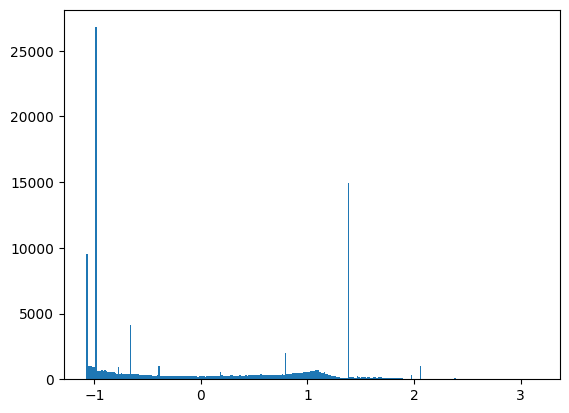

In [6]:
plt.figure()

_ = plt.hist(train_in_norm[:,2], bins=300)

In [7]:
sample_num=config['sampling']['num_samples']
batch_size=config['sampling']['batch_size']
output_dims = test_out_norm.shape[1]

# Define HDF5 structure
filename = 'output/data/emulator_samples.h5'
h5file = tables.open_file(filename, mode='w')
atom = tables.Float32Atom()

# Create extendable array: shape = (0, sample_num * output_dims)
data_storage = h5file.create_earray(
    h5file.root, 'samples', atom,
    shape=(0, sample_num * output_dims)
)
input_storage = h5file.create_earray(
    h5file.root, 'input_reference', atom,
    shape=(0,)
)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for start_idx in range(0, test_in_norm.shape[0], batch_size):
    end_idx = min(start_idx + batch_size, test_in_norm.shape[0])
    
    current_test_in = torch.tensor(
        test_in_norm[start_idx:end_idx, :],
        dtype=torch.float32,
        device=device
    )  # shape: (B, input_dims)

    with torch.no_grad():
        out = sample_net(
            model,
            sample_num,
            current_test_in.T,
            current_test_in.shape[0],  # batch_size
            current_test_in.shape[1],  # input_dims
            output_dims,
            network_type="no_normalizing"
        )  # shape: (B, sample_num, output_dims)

    # Convert and denormalize
    out_np = out.detach().cpu().numpy()  # (B, sample_num, output_dims)
    for i in range(output_dims):
        mean_i, std_i = norm_info_out[i]
        out_np[:, :, i] = out_np[:, :, i] * std_i + mean_i

    # Flatten output to (B, sample_num * output_dims)
    reshaped_out = out_np.reshape(out_np.shape[0], -1)

    # Append to HDF5
    data_storage.append(reshaped_out)

    # Optionally store one input column (e.g., index 2)
    current_input = test_in[start_idx:end_idx, 2]
    input_storage.append(current_input)

    # Progress logging
    percent_done = end_idx * 100 / test_in.shape[0]
    print(f"Processing is {percent_done:.2f}% done")

# Finalize
h5file.close()
print(f"Sampling complete. Data saved to {filename}")


Processing is 7.76% done
Processing is 15.52% done
Processing is 23.28% done
Processing is 31.04% done
Processing is 38.80% done
Processing is 46.55% done
Processing is 54.31% done
Processing is 62.07% done
Processing is 69.83% done
Processing is 77.59% done
Processing is 85.35% done
Processing is 93.11% done
Processing is 100.00% done
Sampling complete. Data saved to output/data/emulator_samples.h5


In [9]:
with tables.open_file(config['output']['sampling_path'], mode='r') as f:
    samples = f.root.samples[:]
    input_vals = f.root.input_reference[:]

In [10]:
samples.shape

(64440, 2000)

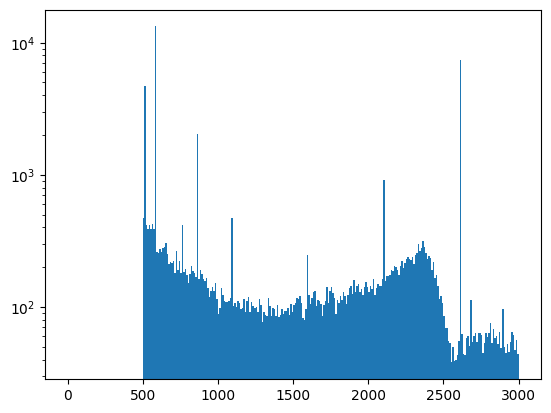

In [11]:
plt.figure()
_ = plt.hist(input_vals, bins=300, range=(0,3000))
plt.yscale('log')

In [12]:
samples.shape, input_vals.shape

((64440, 2000), (64440,))

In [13]:
"""sample_num=1000
batch_size=1000

all_data = pd.DataFrame(columns=[f'col_{i}' for i in range(sample_num * output_dims)], dtype=np.float32)
input_data = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for start_idx in range(0, new_test_in_norm.shape[0], batch_size):
    end_idx = min(start_idx + batch_size, new_test_in_norm.shape[0])
    
    # Slice batch and convert to torch tensor, shape: (batch_size, input_dims)
    current_test_in = torch.tensor(new_test_in_norm[start_idx:end_idx, :], dtype=torch.float32, device=device)
    
    # Transpose to (input_dims, batch_size) as your sample_net expects
    current_test_in_T = current_test_in.T
    
    # Run sample_net: 
    # Inputs: model, sample_num, inputs (input_dims x batch_size), batch_size, input_dims, output_dims, network_type
    out = sample_net(
        model,
        sample_num,
        current_test_in_T,
        current_test_in_T.shape[1],  # batch_size
        current_test_in_T.shape[0],  # input_dims
        output_dims,
        network_type="no_normalizing"  # fix spelling or value based on your model
    )
    
    # out shape: (batch_size, sample_num, output_dims)
    out_np = out.detach().cpu().numpy()
    
    # Denormalize output
    for i in range(output_dims):
        mean_i, std_i = norm_info_out[i]
        out_np[:, :, i] = out_np[:, :, i] * std_i + mean_i
    
    # Denormalize input (if needed for your use case)
    current_test_in_np = current_test_in.cpu().numpy()
    for i in range(current_test_in_np.shape[1]):
        mean_i, std_i = norm_info_in[i]
        current_test_in_np[:, i] = current_test_in_np[:, i] * std_i + mean_i
    
    # Store input feature (e.g., 3rd input column) if needed for later reference
    input_data.append(current_test_in_np[:, 2])
    
    # Reshape output to (batch_size, sample_num * output_dims)
    reshaped_out = out_np.reshape(out_np.shape[0], sample_num * output_dims)
    
    # Append to DataFrame
    out_df = pd.DataFrame(reshaped_out, columns=[f'col_{i}' for i in range(reshaped_out.shape[1])])
    all_data = pd.concat([all_data, out_df], ignore_index=True)
    
    # Progress report
    percent_done = (end_idx) * 100 / new_test_in_norm.shape[0]
    print(f"Processing is {percent_done:.2f}% done")"""

'sample_num=1000\nbatch_size=1000\n\nall_data = pd.DataFrame(columns=[f\'col_{i}\' for i in range(sample_num * output_dims)], dtype=np.float32)\ninput_data = []\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nfor start_idx in range(0, new_test_in_norm.shape[0], batch_size):\n    end_idx = min(start_idx + batch_size, new_test_in_norm.shape[0])\n\n    # Slice batch and convert to torch tensor, shape: (batch_size, input_dims)\n    current_test_in = torch.tensor(new_test_in_norm[start_idx:end_idx, :], dtype=torch.float32, device=device)\n\n    # Transpose to (input_dims, batch_size) as your sample_net expects\n    current_test_in_T = current_test_in.T\n\n    # Run sample_net: \n    # Inputs: model, sample_num, inputs (input_dims x batch_size), batch_size, input_dims, output_dims, network_type\n    out = sample_net(\n        model,\n        sample_num,\n        current_test_in_T,\n        current_test_in_T.shape[1],  # batch_size\n        current_test_in_T.shape[

In [14]:
samples[:, 1]

array([0.8181943 , 0.49621955, 0.8155106 , ..., 0.7919485 , 0.7852161 ,
       0.7395865 ], shape=(64440,), dtype=float32)

In [15]:
reshaped_data_ = samples.reshape(len(samples), 1000, 2)  # (B, S, D)
reshaped_data_[0][0]

array([1.1290765e+03, 8.1819433e-01], dtype=float32)

1127.4596


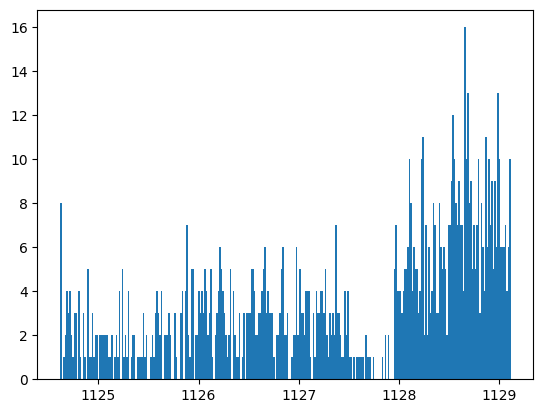

In [17]:
plt.figure()

_ = plt.hist(reshaped_data_[0,:, 0], bins=300)
print(np.mean(reshaped_data_[0,:, 0]))
# plt.yscale('log')

In [18]:
peak_data = {
    "fep": {"Evals": [], "Avals": [], "count": 0, "offset": 0},
    "dep": {"Evals": [], "Avals": [], "count": 0, "offset": 1022},
    "sep": {"Evals": [], "Avals": [], "count": 0, "offset": 511},
}

for i in range(len(input_vals)):
    E = input_vals[i]

    for peak, info in peak_data.items():
        E_shifted = E - 2615 + info["offset"]
        if abs(E_shifted) < 5:
            info["count"] += 1
            vals = samples[i, 0::2]  # every second column starting from 0
            info["Evals"].extend(vals.tolist())  # Or use .append(vals) for 2D list
            vals = samples[i, 1::2]  # every second column starting from 0
            info["Avals"].extend(vals.tolist())  # Or use .append(vals) for 2D list

# Access results
fep_Evals = peak_data["fep"]["Evals"]
fep_Avals = peak_data["fep"]["Avals"]
nfep = peak_data["fep"]["count"]

dep_Evals = peak_data["dep"]["Evals"]
dep_Avals = peak_data["dep"]["Avals"]
ndep = peak_data["dep"]["count"]

sep_Evals = peak_data["sep"]["Evals"]
sep_Avals = peak_data["sep"]["Avals"]
nsep = peak_data["sep"]["count"]


In [19]:
"""fep_vals = []
nfep = 0
dep_vals = []
ndep = 0
sep_vals = []
nsep = 0
for i in range(len(input_vals)):
        index = i*1000 + j
        E = input_data[i][j]

        E_diff_fep = E - 2615
        E_diff_dep = E - 2615 + 1022
        E_diff_sep = E - 2615 + 511

        if abs(E_diff_fep) < 5 :
            nfep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    fep_vals.append(val)
        
        if abs(E_diff_dep) < 5 :
            ndep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    dep_vals.append(val)

        if abs(E_diff_sep) < 5 :
            nsep += 1
            for k, col in enumerate(all_data.columns):
                if k % 2:
                    val = all_data[col].loc[index]
                    sep_vals.append(val)"""

'fep_vals = []\nnfep = 0\ndep_vals = []\nndep = 0\nsep_vals = []\nnsep = 0\nfor i in range(len(input_vals)):\n        index = i*1000 + j\n        E = input_data[i][j]\n\n        E_diff_fep = E - 2615\n        E_diff_dep = E - 2615 + 1022\n        E_diff_sep = E - 2615 + 511\n\n        if abs(E_diff_fep) < 5 :\n            nfep += 1\n            for k, col in enumerate(all_data.columns):\n                if k % 2:\n                    val = all_data[col].loc[index]\n                    fep_vals.append(val)\n\n        if abs(E_diff_dep) < 5 :\n            ndep += 1\n            for k, col in enumerate(all_data.columns):\n                if k % 2:\n                    val = all_data[col].loc[index]\n                    dep_vals.append(val)\n\n        if abs(E_diff_sep) < 5 :\n            nsep += 1\n            for k, col in enumerate(all_data.columns):\n                if k % 2:\n                    val = all_data[col].loc[index]\n                    sep_vals.append(val)'

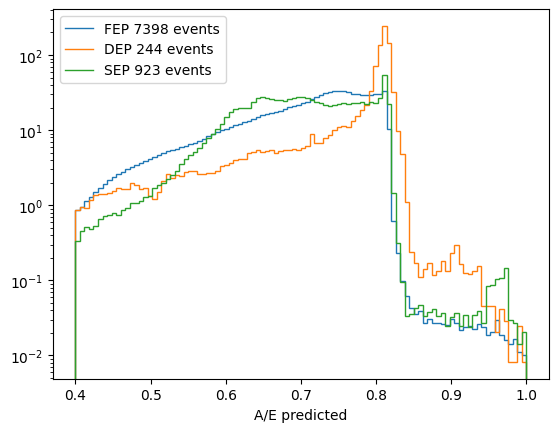

In [20]:
plt.figure()

freq, bin_edges = np.histogram(fep_Avals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/nfep, bin_edges, label=f'FEP {nfep} events')

freq, bin_edges = np.histogram(dep_Avals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/ndep, bin_edges, label=f'DEP {ndep} events')

freq, bin_edges = np.histogram(sep_Avals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/nsep, bin_edges, label=f'SEP {nsep} events')

plt.legend()

# plt.yscale('log')
plt.xlabel('A/E predicted')
# plt.ylabel('pdf')

plt.yscale('log')

Text(0, 0.5, 'pdf')

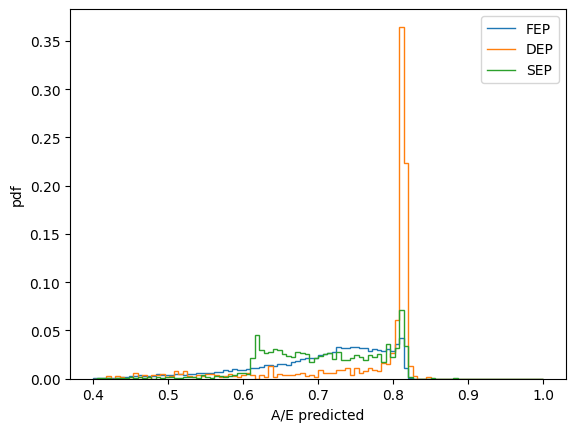

In [21]:
plt.figure()

all_fep_vals = []
all_dep_vals = []
all_sep_vals = []
for i in range(len(train_in)):
    E_true = train_in[i][2]
    AoE = train_out[i][1]
    E_diff = E_true - 2615
    if abs(E_diff) < 10:
        all_fep_vals.append(AoE)

    E_diff = E_true - 2615 + 511 + 511
    if abs(E_diff) < 10:
        all_dep_vals.append(AoE)

    E_diff = E_true - 2615 + 511
    if abs(E_diff) < 10:
        all_sep_vals.append(AoE)

freq, bin_edges = np.histogram(all_fep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='FEP')
freq, bin_edges = np.histogram(all_dep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='DEP')
freq, bin_edges = np.histogram(all_sep_vals, bins=100, range=(0.4, 1))
_ = plt.stairs(freq/sum(freq), bin_edges, label='SEP')

plt.legend()

# plt.yscale('log')
plt.xlabel('A/E predicted')
plt.ylabel('pdf')

In [22]:
def calc_quant(data, vals):
    n = data.shape[1]
    left = np.count_nonzero(vals < data, axis=1)
    right = np.count_nonzero(vals <= data, axis=1)
    pct = (right + left + np.where(right>left, 1+0*right, 0*right)) /(2*n)
    return pct

In [23]:
"""columns = ['Column1', 'Column2']

# Create DataFrames
median_prediction_df = pd.DataFrame(columns=columns)
mean_prediction_df = pd.DataFrame(columns=columns)
gen_quantile_df = pd.DataFrame(columns=columns)

total_samples = data.shape[0]
for x in range(total_samples//batch_size+1):
    actual_batch_size = min((x+1)*batch_size, total_samples)- x*batch_size
    
    # Extract the batch from the DataFrame
    batch_data = all_data.iloc[x*batch_size:min((x + 1) * batch_size, total_samples)]

    # Convert DataFrame to NumPy array
    data_array = batch_data.to_numpy()

    reshaped_array = data_array.reshape(data_array.shape[0]*data_array.shape[1]//output_dims, output_dims)

    # true_data = df_data[['Es', 'AoEs']].iloc[x*batch_size:min((x+1)*batch_size, total_samples)].to_numpy()
    true_data = new_test_out[x*batch_size:min((x + 1) * batch_size, total_samples), :]
    
    reshaped_data = reshaped_array.reshape(
        (reshaped_array.shape[0]//actual_batch_size, actual_batch_size, output_dims),
        order="f"
    )

    all_quants = []
    all_means = []
    all_medians = []

    for y in range(output_dims):
        true_val = reshaped_data[:,:,y].T
        pred_val = true_data[:,y:y+1] # This order is in the file - not sure why they are named this way
        # pred_val = reshaped_data[:,:,y].T
        # true_val = true_data[:,y:y+1]
        quants = calc_quant(true_val, pred_val)
        medians = np.median(reshaped_data[:,:,y], axis=0)
        means = np.mean(reshaped_data[:,:,y], axis=0)

        all_quants.append(np.expand_dims(quants, axis=1))
        all_medians.append(np.expand_dims(medians, axis=1))
        all_means.append(np.expand_dims(means, axis=1))

    all_quants_df = pd.DataFrame(np.concatenate(all_quants, axis=1), columns=columns)
    all_medians_df = pd.DataFrame(np.concatenate(all_medians, axis=1), columns=columns)
    all_means_df = pd.DataFrame(np.concatenate(all_means, axis=1), columns=columns)

    median_prediction_df = pd.concat([median_prediction_df, all_medians_df], ignore_index=True)
    mean_prediction_df = pd.concat([mean_prediction_df, all_means_df], ignore_index=True)
    gen_quantile_df = pd.concat([gen_quantile_df, all_quants_df], ignore_index=True) 
    
    print(str(100*min((x+1)*batch_size, total_samples)/total_samples)+"% done")"""

'columns = [\'Column1\', \'Column2\']\n\n# Create DataFrames\nmedian_prediction_df = pd.DataFrame(columns=columns)\nmean_prediction_df = pd.DataFrame(columns=columns)\ngen_quantile_df = pd.DataFrame(columns=columns)\n\ntotal_samples = data.shape[0]\nfor x in range(total_samples//batch_size+1):\n    actual_batch_size = min((x+1)*batch_size, total_samples)- x*batch_size\n\n    # Extract the batch from the DataFrame\n    batch_data = all_data.iloc[x*batch_size:min((x + 1) * batch_size, total_samples)]\n\n    # Convert DataFrame to NumPy array\n    data_array = batch_data.to_numpy()\n\n    reshaped_array = data_array.reshape(data_array.shape[0]*data_array.shape[1]//output_dims, output_dims)\n\n    # true_data = df_data[[\'Es\', \'AoEs\']].iloc[x*batch_size:min((x+1)*batch_size, total_samples)].to_numpy()\n    true_data = new_test_out[x*batch_size:min((x + 1) * batch_size, total_samples), :]\n\n    reshaped_data = reshaped_array.reshape(\n        (reshaped_array.shape[0]//actual_batch_size,

In [42]:
output_dims = test_out.shape[1]
num_samples = config["sampling"]["num_samples"]
total_samples = samples.shape[0]
batch_size = config["sampling"]["batch_size"]

# Pre-allocate full arrays
median_predictions = np.empty((total_samples, output_dims), dtype=np.float32)
mean_predictions = np.empty((total_samples, output_dims), dtype=np.float32)
quantile_errors = np.empty((total_samples, output_dims), dtype=np.float32)

num_batches = (total_samples + batch_size - 1) // batch_size

for x in range(num_batches):
    start = x * batch_size
    end = min((x + 1) * batch_size, total_samples)
    actual_batch_size = end - start

    # Slice and reshape
    batch_data = samples[start:end]  # (B, S * D)
    reshaped_data = batch_data.reshape(actual_batch_size, num_samples, output_dims)  # (B, S, D)
    true_data = test_out[start:end, :]  # (B, D)

    for y in range(output_dims):
        sample_y = reshaped_data[:, :, y]     # (B, S)
        true_y = true_data[:, y:y+1]          # (B, 1)
        # Calculate stats
        quant_err = calc_quant(sample_y, true_y)           # (B,)
        median_vals = np.median(sample_y, axis=1)          # (B,)
        mean_vals = np.mean(sample_y, axis=1)              # (B,)
        
        quantile_errors[start:end, y] = quant_err
        median_predictions[start:end, y] = median_vals
        mean_predictions[start:end, y] = mean_vals


In [43]:
columns = ['Column1', 'Column2']

# Final DataFrames
median_prediction_df = pd.DataFrame(columns=columns)
mean_prediction_df = pd.DataFrame(columns=columns)
gen_quantile_df = pd.DataFrame(columns=columns)

total_samples = samples.shape[0]
batch_size = 5000
num_batches = total_samples // batch_size + int(total_samples % batch_size != 0)

for x in range(num_batches):
    start = x * batch_size
    end = min((x + 1) * batch_size, total_samples)
    actual_batch_size = end - start

    # Extract the batch from the full numpy array (no DataFrame)
    batch_data = samples[start:end]  # shape: (batch_size, sample_num * output_dims)
    reshaped_array = batch_data.reshape(
        actual_batch_size * sample_num, output_dims
    )

    # Reshape to: (sample_num, batch_size, output_dims)
    reshaped_data = reshaped_array.reshape(
        actual_batch_size, sample_num, output_dims
    )

    # True output data
    true_data = test_out[start:end, :]  # shape: (batch_size, output_dims)

    # Compute stats
    all_quants = []
    all_means = []
    all_medians = []

    for y in range(output_dims):
        _samples = reshaped_data[:, :, y]  # shape: (batch_size, sample_num)
        true_vals = true_data[:, y:y+1]     # shape: (batch_size, 1)

        # Compute generalised quantiles
        quants = calc_quant(_samples, true_vals)  # shape: (batch_size,)
        medians = np.median(_samples, axis=1)     # shape: (batch_size,)
        means = np.mean(_samples, axis=1)         # shape: (batch_size,)

        all_quants.append(quants.reshape(-1, 1))
        all_medians.append(medians.reshape(-1, 1))
        all_means.append(means.reshape(-1, 1))

    # Stack per output_dim
    all_quants_df = pd.DataFrame(np.hstack(all_quants), columns=columns)
    all_medians_df = pd.DataFrame(np.hstack(all_medians), columns=columns)
    all_means_df = pd.DataFrame(np.hstack(all_means), columns=columns)

    # Accumulate
    median_prediction_df = pd.concat([median_prediction_df, all_medians_df], ignore_index=True)
    mean_prediction_df = pd.concat([mean_prediction_df, all_means_df], ignore_index=True)
    gen_quantile_df = pd.concat([gen_quantile_df, all_quants_df], ignore_index=True)

    print(f"{100 * end / total_samples:.2f}% done")


/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_59114/1884690695.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  median_prediction_df = pd.concat([median_prediction_df, all_medians_df], ignore_index=True)
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_59114/1884690695.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mean_prediction_df = pd.concat([mean_prediction_df, all_means_df], ignore_index=True)
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_59114

7.76% done
15.52% done
23.28% done
31.04% done
38.80% done
46.55% done
54.31% done
62.07% done
69.83% done
77.59% done
85.35% done
93.11% done
100.00% done


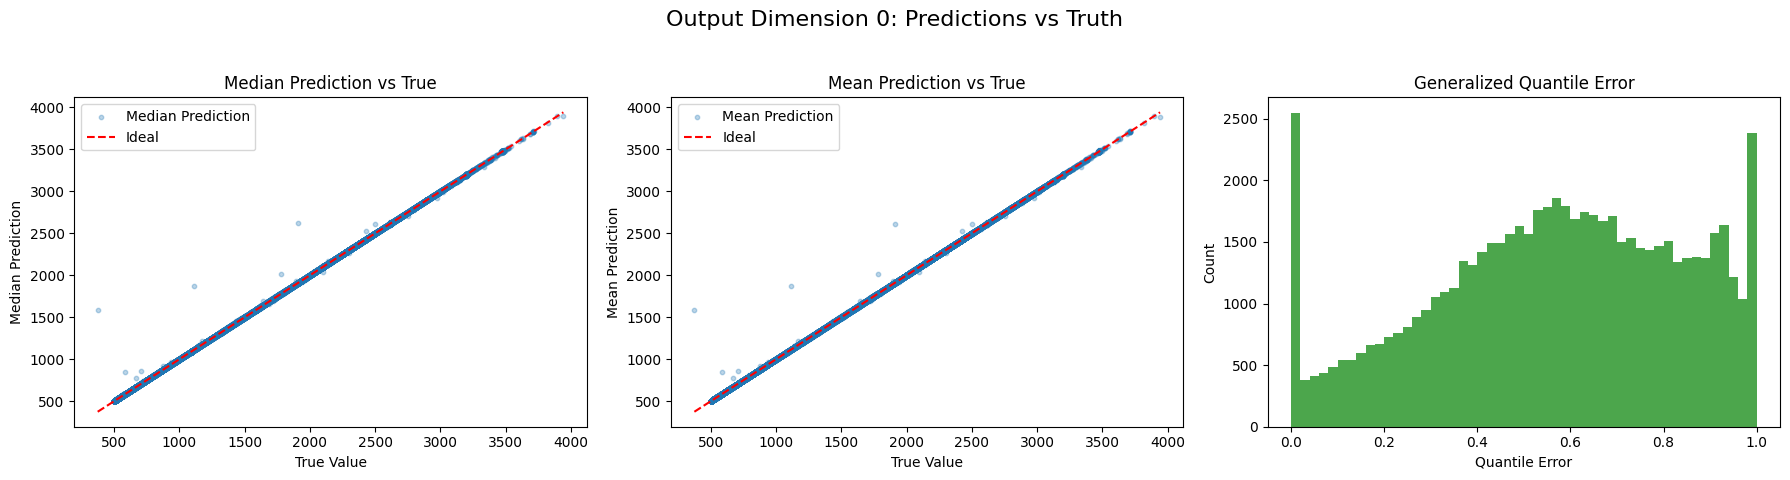

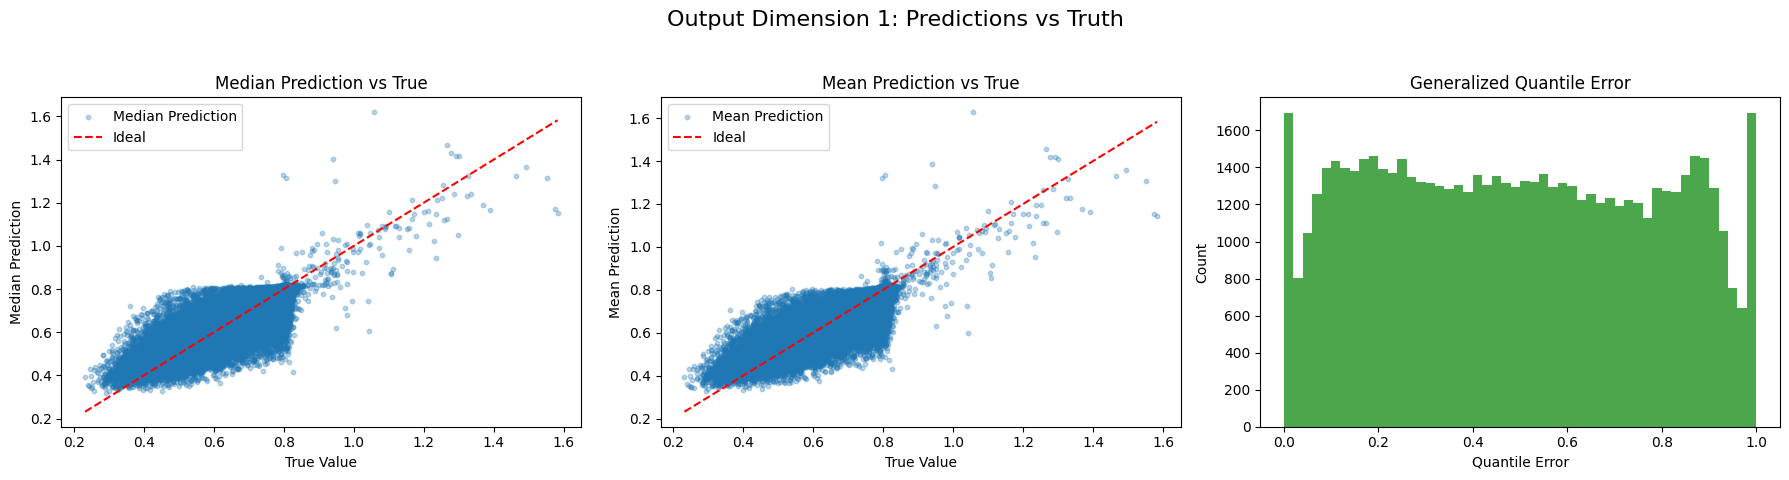

In [44]:
# Ensure output_dims matches the number of columns
assert test_out.shape[1] == output_dims

for i in range(output_dims):
    true_vals = test_out[:, i]
    median_preds = median_prediction_df.iloc[:, i]
    mean_preds = mean_prediction_df.iloc[:, i]
    quant_errors = gen_quantile_df.iloc[:, i]

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Output Dimension {i}: Predictions vs Truth', fontsize=16)

    # Median vs Truth
    axs[0].scatter(true_vals, median_preds, alpha=0.3, label='Median Prediction', s=10)
    axs[0].plot([true_vals.min(), true_vals.max()], [true_vals.min(), true_vals.max()], 'r--', label='Ideal')
    axs[0].set_title('Median Prediction vs True')
    axs[0].set_xlabel('True Value')
    axs[0].set_ylabel('Median Prediction')
    axs[0].legend()

    # Mean vs Truth
    axs[1].scatter(true_vals, mean_preds, alpha=0.3, label='Mean Prediction', s=10)
    axs[1].plot([true_vals.min(), true_vals.max()], [true_vals.min(), true_vals.max()], 'r--', label='Ideal')
    axs[1].set_title('Mean Prediction vs True')
    axs[1].set_xlabel('True Value')
    axs[1].set_ylabel('Mean Prediction')
    axs[1].legend()

    # Generalized Quantile Error
    axs[2].hist(quant_errors, bins=50, alpha=0.7, color='g')
    axs[2].set_title('Generalized Quantile Error')
    axs[2].set_xlabel('Quantile Error')
    axs[2].set_ylabel('Count')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

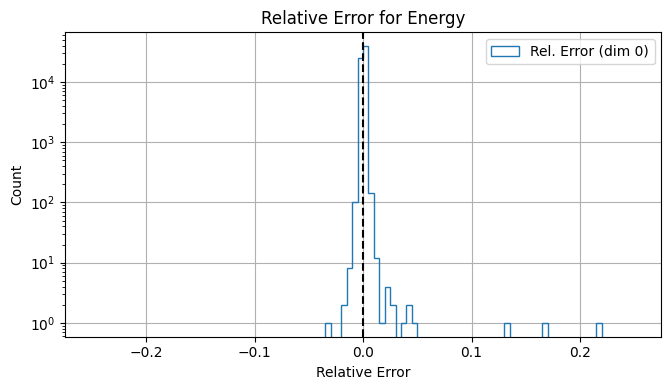

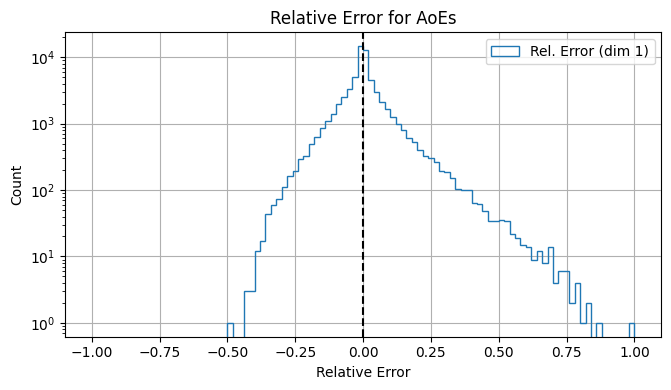

In [37]:
output_dims = test_out.shape[1]
ranges = [(-0.25, 0.25), (-1, 1)]
titles = ["Energy", "AoEs"]
for i in range(output_dims):
    # Extract predicted and true values for this output dimension
    pred_median = median_prediction_df.iloc[:, i].to_numpy()
    true_vals = test_out[:, i]

    # Handle NaNs safely
    weights = ~np.isnan(pred_median)
    pred_median = np.where(weights, pred_median, 0)
    true_vals = np.where(weights, true_vals, 1)  # prevent division by 0

    # Calculate relative error
    abs_error = pred_median - true_vals
    rel_error = abs_error / true_vals

    # Plot histogram
    plt.figure(figsize=(7, 4))
    plt.hist(rel_error, range=ranges[i], bins=100, histtype='step', label=f'Rel. Error (dim {i})')
    plt.axvline(0, color='k', linestyle='--')
    plt.xlabel("Relative Error")
    plt.ylabel("Count")
    plt.title(f"Relative Error for {titles[i]}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')

In [38]:
"""all_counts=[]
all_edges=[]
quant_counts=[]
quant_edges=[]
total_counts = 0
bins=50

ranges= [[0,3000],[0,1]]

for x in range(total_samples//batch_size+1):

    pred_counts=[]
    actual_batch_size = min((x+1)*batch_size, total_samples)- x*batch_size

    temp_ydata = ydata[x*batch_size:min((x+1)*batch_size, total_samples),:]
    pred_data = all_data.to_numpy()[x*batch_size:min((x+1)*batch_size, total_samples),:]
    temp_xdata = xdata[x*batch_size:min((x+1)*batch_size, total_samples),:]
    
    quants = gen_quantile_df.to_numpy()[x*batch_size:min((x+1)*batch_size, total_samples),:]
    weights = np.ones(temp_xdata[:,0].shape)
    total_counts+=np.sum(weights)

    for z in range(num_samples):
        current_data = pred_data[:,output_dims*z:output_dims*(z+1)]
        temp = []
        for y in range(output_dims):
            counts, _ = np.histogram(current_data[:,y], range=ranges[y], bins=bins, weights=weights)
            temp.append(counts)
        pred_counts.append(temp)
    pred_counts = np.array(pred_counts)

    for y in range(output_dims):
        #reco_counts, edges = np.histogram(recoData[:,y], range=ranges[y], bins=bins, weights=weights)
        true_counts, edges = np.histogram(temp_ydata[:,y], range=ranges[y], bins=bins, weights=weights)
        edges = edges[1:]/2+edges[:-1]/2
        q_counts, q_edges = np.histogram(quants[:,y], range=(0,1), bins=bins, weights=weights)
        q_edges = q_edges[1:]

        if(x==0):
            # all_counts.append([reco_counts, pred_counts[:,y,:], gen_counts])
            all_counts.append([pred_counts[:,y,:], true_counts])
            all_edges.append(edges)
            quant_counts.append([q_counts])
            quant_edges.append(q_edges)
        else:
            # all_counts[y][0]+=reco_counts
            all_counts[y][0]+=pred_counts[:,y,:]
            all_counts[y][1]+=true_counts
            quant_counts[y] +=q_counts

print("Total counts", total_counts)    
print("Total samples", total_samples) """

'all_counts=[]\nall_edges=[]\nquant_counts=[]\nquant_edges=[]\ntotal_counts = 0\nbins=50\n\nranges= [[0,3000],[0,1]]\n\nfor x in range(total_samples//batch_size+1):\n\n    pred_counts=[]\n    actual_batch_size = min((x+1)*batch_size, total_samples)- x*batch_size\n\n    temp_ydata = ydata[x*batch_size:min((x+1)*batch_size, total_samples),:]\n    pred_data = all_data.to_numpy()[x*batch_size:min((x+1)*batch_size, total_samples),:]\n    temp_xdata = xdata[x*batch_size:min((x+1)*batch_size, total_samples),:]\n\n    quants = gen_quantile_df.to_numpy()[x*batch_size:min((x+1)*batch_size, total_samples),:]\n    weights = np.ones(temp_xdata[:,0].shape)\n    total_counts+=np.sum(weights)\n\n    for z in range(num_samples):\n        current_data = pred_data[:,output_dims*z:output_dims*(z+1)]\n        temp = []\n        for y in range(output_dims):\n            counts, _ = np.histogram(current_data[:,y], range=ranges[y], bins=bins, weights=weights)\n            temp.append(counts)\n        pred_cou

In [39]:
all_counts = []       # One per output_dim: [sampled_preds (N_bins x N_samples), true_counts]
all_edges = []        # Bin centers for plotting
quant_counts = []     # One per output_dim
quant_edges = []      # Bin edges for quantile hist
total_counts = 0

bins = 50
ranges = [[0, 3000], [0, 1]]  # One range per output dim

num_batches = total_samples // batch_size + int(total_samples % batch_size != 0)

for x in range(num_batches):
    start = x * batch_size
    end = min((x + 1) * batch_size, total_samples)
    actual_batch_size = end - start

    # Slice data
    temp_ydata = test_out[start:end, :]                           # (B, D)
    pred_data = samples[start:end, :]              # (B, S*D)
    temp_xdata = test_in[start:end, :]                           # (B, ?)
    quants = gen_quantile_df.to_numpy()[start:end, :]          # (B, D)

    weights = np.ones(temp_xdata.shape[0])
    total_counts += np.sum(weights)

    # Reshape pred_data to (B, S, D)
    pred_data = pred_data.reshape(actual_batch_size, -1, output_dims)

    # Compute predicted sample histograms
    pred_counts = []
    for d in range(output_dims):
        dim_preds = pred_data[:, :, d]  # (B, S)
        dim_preds = dim_preds.T         # (S, B) for histogram loop

        counts_per_sample = []
        for s in range(dim_preds.shape[0]):
            counts, _ = np.histogram(dim_preds[s], range=ranges[d], bins=bins, weights=weights)
            counts_per_sample.append(counts)
        counts_per_sample = np.array(counts_per_sample)  # (S, bins)
        pred_counts.append(counts_per_sample)

    # True value histogram
    for d in range(output_dims):
        true_counts, edges = np.histogram(temp_ydata[:, d], range=ranges[d], bins=bins, weights=weights)
        bin_centers = (edges[1:] + edges[:-1]) / 2

        # Quantile histogram (0–1 always)
        q_counts, q_edges = np.histogram(quants[:, d], range=(0, 1), bins=bins, weights=weights)

        if x == 0:
            all_counts.append([pred_counts[d], true_counts])
            all_edges.append(bin_centers)
            quant_counts.append(q_counts)
            quant_edges.append(q_edges[1:])  # right edge for each bin
        else:
            all_counts[d][0] += pred_counts[d]
            all_counts[d][1] += true_counts
            quant_counts[d] += q_counts

print("Total counts:", total_counts)
print("Total samples:", total_samples)


Total counts: 64440.0
Total samples: 64440


In [40]:
"""labels=["E", "A/E"]
titles=["E", "A/E"]
for x in range(output_dims):
    q_sums = [quant_counts[x][0,0]]
    for y in range(1, len(q_counts)):
        q_sums.append(q_sums[-1]+quant_counts[x][0,y])
    fig, (ax1) = plt.subplots(1, 1, figsize=(6,3))#, gridspec_kw={'height_ratios': [0.5, 1]})
    ax1.scatter(q_edges, bins*quant_counts[x][0,:]/np.sum(quant_counts[x][0,:]), c="#d7301f", label="predicted")
    ax1.plot(q_edges, q_edges*0+1, c="k", linestyle="--", label="target")
    # ax1.set_ylim((0.7,1.3))
    ax1.set_ylabel("p(quantile)")
    ax1.set_xlabel("quantile")
    ax1.set_title(labels[x])
    ax1.legend()
    plt.tight_layout()
    # fig.subplots_adjust(wspace=0.0, hspace=0.1)"""

'labels=["E", "A/E"]\ntitles=["E", "A/E"]\nfor x in range(output_dims):\n    q_sums = [quant_counts[x][0,0]]\n    for y in range(1, len(q_counts)):\n        q_sums.append(q_sums[-1]+quant_counts[x][0,y])\n    fig, (ax1) = plt.subplots(1, 1, figsize=(6,3))#, gridspec_kw={\'height_ratios\': [0.5, 1]})\n    ax1.scatter(q_edges, bins*quant_counts[x][0,:]/np.sum(quant_counts[x][0,:]), c="#d7301f", label="predicted")\n    ax1.plot(q_edges, q_edges*0+1, c="k", linestyle="--", label="target")\n    # ax1.set_ylim((0.7,1.3))\n    ax1.set_ylabel("p(quantile)")\n    ax1.set_xlabel("quantile")\n    ax1.set_title(labels[x])\n    ax1.legend()\n    plt.tight_layout()\n    # fig.subplots_adjust(wspace=0.0, hspace=0.1)'

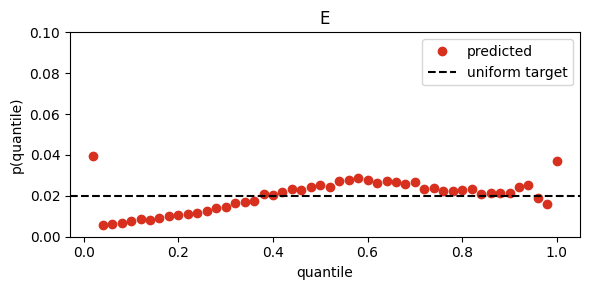

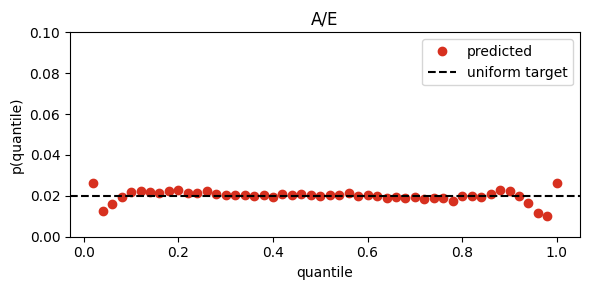

In [41]:
import matplotlib.pyplot as plt

labels = ["E", "A/E"]
titles = ["E", "A/E"]

for x in range(output_dims):
    fig, ax1 = plt.subplots(1, 1, figsize=(6, 3))

    # Get quantile histogram info
    counts = quant_counts[x]  # shape: (bins,)
    edges = quant_edges[x]   # shape: (bins,)
    centers = (edges[1:] + edges[:-1]) / 2 if len(edges) == bins + 1 else edges

    # Normalize
    normalized = counts / np.sum(counts)

    # Plot predicted quantile distribution
    ax1.plot(centers, normalized, "o", color="#d7301f", label="predicted")
    ax1.axhline(1.0 / bins, color="k", linestyle="--", label="uniform target")

    ax1.set_ylabel("p(quantile)")
    ax1.set_xlabel("quantile")
    ax1.set_title(titles[x])
    ax1.set_ylim(0,0.1)
    ax1.legend()
    plt.tight_layout()


In [32]:
pred50 = []
pred16 = []
pred84 = []
for x in range(output_dims):
    pred50.append(np.quantile(all_counts[x][0], 0.5, axis=0))
    pred16.append(np.quantile(all_counts[x][0], 0.16, axis=0))
    pred84.append(np.quantile(all_counts[x][0], 0.84, axis=0))

/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_59114/1318652502.py:17: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(all_edges[x], all_counts[x][1]/all_counts[x][1], color="k", marker="o",facecolors="none", s=5, linewidth=0.5)
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_59114/1318652502.py:19: RuntimeWarning: invalid value encountered in divide
  all_edges[x], pred50[x]/all_counts[x][1],
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_59114/1318652502.py:20: RuntimeWarning: invalid value encountered in divide
  xerr=0, yerr=[pred50[x]/all_counts[x][1]- pred16[x]/all_counts[x][1], pred84[x]/all_counts[x][1]-pred50[x]/all_counts[x][1]],
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h5400000gn/T/ipykernel_59114/1318652502.py:17: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(all_edges[x], all_counts[x][1]/all_counts[x][1], color="k", marker="o",facecolors="none", s=5, linewidth=0.5)
/var/folders/sh/c4zm4mfn7xl1vd5v3vp3h540

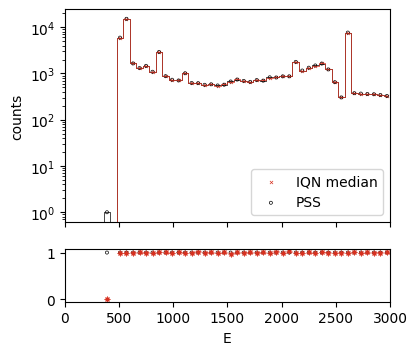

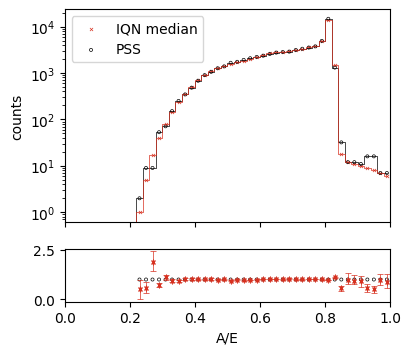

In [33]:
for x in range(output_dims):      
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.5*3/2.5,3.8), gridspec_kw={'height_ratios': [2,0.5]})
    
    ax1.step(all_edges[x], all_counts[x][1], where="mid", color="k", linewidth=0.5)#, linestyle="-.")
    ax1.step(all_edges[x], pred50[x], where="mid", color="#d7301f", linewidth=0.5)
    ax1.scatter(all_edges[x], pred50[x], label="IQN median", color="#d7301f", marker="x", s=5, linewidth=0.5)
    ax1.scatter(all_edges[x], all_counts[x][1], label="PSS",  color="k",facecolors='none', marker="o", s=5, linewidth=0.5)
    
    ax1.set_xlim(ranges[x])
    # ax1.set_ylim(0, max(all_counts[x][0])*1.1)
    ax1.set_ylabel("counts")
    ax1.set_xticklabels([])
    ax1.legend()

    ax1.set_yscale('log')
    
    ax2.scatter(all_edges[x], all_counts[x][1]/all_counts[x][1], color="k", marker="o",facecolors="none", s=5, linewidth=0.5)
    ax2.errorbar(
        all_edges[x], pred50[x]/all_counts[x][1],
        xerr=0, yerr=[pred50[x]/all_counts[x][1]- pred16[x]/all_counts[x][1], pred84[x]/all_counts[x][1]-pred50[x]/all_counts[x][1]],
        color="#d7301f", ls="",
        capsize=2,capthick=0.5, marker="x", linewidth=0.5, markersize=np.sqrt(5)
    )

    ax2.set_xlabel(labels[x])
    #ax2.set_ylabel(r"$\frac{\textnormal{predicted}}{\textnormal{gen}}$")
    # ax2.set_ylim((0.9,1.1))
    ax2.set_xlim(ranges[x])

    
    # plt.tight_layout()
    #fig.subplots_adjust(wspace=0.0, hspace=0.1)